# 库存ABC分类分析 — Superstore数据集

**业务场景：** 作为一家消费电子与办公用品零售商的供应链分析师，需要对200个核心产品进行ABC分类，据此制定差异化的库存管理策略。

**数据来源：** Tableau Superstore 数据集（9,994条交易记录，聚合为200个产品）

**分析方法：**
- 计算每个产品的年度消耗金额（Annual Dollar Volume = 年需求量 × 单位成本）
- 按消耗金额降序排列，计算累计百分比
- A类：前80%累计消耗金额 | B类：80%-95% | C类：后5%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti SC', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')
sns.set_palette('husl')
print('✅ Libraries loaded successfully')


✅ Libraries loaded successfully


## 1. 数据加载与准备

从 Superstore 数据集中加载聚合后的产品级数据。每条记录代表一个产品的年需求量、单位成本和年度消耗金额。


In [2]:
# Load real retail data
df = pd.read_csv('../data/superstore_products.csv')

# Display basic information
print(f'Total products: {len(df)}')
print(f'Total categories: {df.Category.nunique()}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nData sample:')
display(df.head(8))

# Calculate Annual Dollar Volume
df['Annual_Volume'] = df['Annual_Demand'] * df['Unit_Cost']

# Sort by volume descending
df = df.sort_values('Annual_Volume', ascending=False).reset_index(drop=True)

# Calculate percentages
total_volume = df['Annual_Volume'].sum()
df['Volume_Pct'] = (df['Annual_Volume'] / total_volume * 100).round(2)
df['Cumulative_Pct'] = df['Volume_Pct'].cumsum().round(2)

print(f'\n📊 Total Annual Dollar Volume: ${total_volume:,.2f}')
print(f'📊 Volume Range: ${df.Annual_Volume.min():,.2f} — ${df.Annual_Volume.max():,.2f}')
print(f'📊 Average Unit Cost: ${df.Unit_Cost.mean():,.2f}')


Total products: 200
Total categories: 3

Columns: ['Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Annual_Demand', 'Annual_Revenue', 'Order_Count', 'Unit_Cost']

Data sample:


,Product_ID,Product_Name,Category,Sub_Category,Annual_Demand,Annual_Revenue,Order_Count,Unit_Cost
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,20,61599.824,5,3079.991200
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,31,27453.384,10,885.593032
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,6,22638.480,1,3773.080000
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,39,21870.576,8,560.784000
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,37,19823.479,11,535.769703
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,48,19024.500,9,396.343750
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,38,18839.686,8,495.781211
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,12,18374.895,3,1531.241250



📊 Total Annual Dollar Volume: $1,385,576.74
📊 Volume Range: $3,044.16 — $61,599.82
📊 Average Unit Cost: $346.24


## 2. ABC 分类

根据累计消耗金额百分比将产品分为三类：
- **A类（前80%）**：高价值产品，需要严格管控
- **B类（80%-95%）**：中等价值产品，适度管控
- **C类（后5%）**：低价值产品，简化管控


### 帕累托原理验证

在分类之前，先验证数据是否符合帕累托分布（前 20% 的产品是否贡献了约 80% 的价值）。

In [3]:
def classify_abc(cum_pct):
    """Classify product based on cumulative percentage."""
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'

df['ABC_Class'] = df['Cumulative_Pct'].apply(classify_abc)

# Summary statistics by ABC class
summary = df.groupby('ABC_Class').agg(
    Product_Count=('Product_ID', 'count'),
    Total_Volume=('Annual_Volume', 'sum'),
    Avg_Unit_Cost=('Unit_Cost', 'mean'),
    Avg_Demand=('Annual_Demand', 'mean')
).round(2)

summary['Volume_Pct'] = (summary['Total_Volume'] / total_volume * 100).round(1)
summary['Item_Pct'] = (summary['Product_Count'] / len(df) * 100).round(1)

print('📊 ABC Classification Summary:')
print('=' * 70)
display(summary)
print()
for cls in ['A', 'B', 'C']:
    row = summary.loc[cls]
    print(f'🔹 Class {cls}: {int(row["Product_Count"])} products ({row["Item_Pct"]}% of items), '
          f'${row["Total_Volume"]:,.0f} volume ({row["Volume_Pct"]}% of total)')


📊 ABC Classification Summary:


,Product_Count,Total_Volume,Avg_Unit_Cost,Avg_Demand,Volume_Pct,Item_Pct
ABC_Class,,,,,,
A,125,1104540.29,426.89,27.48,79.7,62.5
B,53,209742.06,228.63,24.96,15.1,26.5
C,22,71294.38,171.36,24.36,5.1,11.0



🔹 Class A: 125 products (62.5% of items), $1,104,540 volume (79.7% of total)
🔹 Class B: 53 products (26.5% of items), $209,742 volume (15.1% of total)
🔹 Class C: 22 products (11.0% of items), $71,294 volume (5.1% of total)


In [ ]:
# 验证帕累托原理 (Pareto Principle)
top_20_pct = int(len(df) * 0.2)
top_20_volume = df.head(top_20_pct)['Annual_Volume'].sum() / total_volume * 100
print(f'前 20% 的 SKU ({top_20_pct} 个) 贡献了 {top_20_volume:.1f}% 的库存价值')
print(f'前 50% 的 SKU ({int(len(df)*0.5)} 个) 贡献了 {df.head(int(len(df)*0.5))["Annual_Volume"].sum()/total_volume*100:.1f}%')
print(f'→ {"符合" if top_20_volume > 70 else "不完全符合"}帕累托分布 (80/20 法则)')


## 3. 可视化

生成帕累托图和分类分布图，直观展示ABC分析结果。


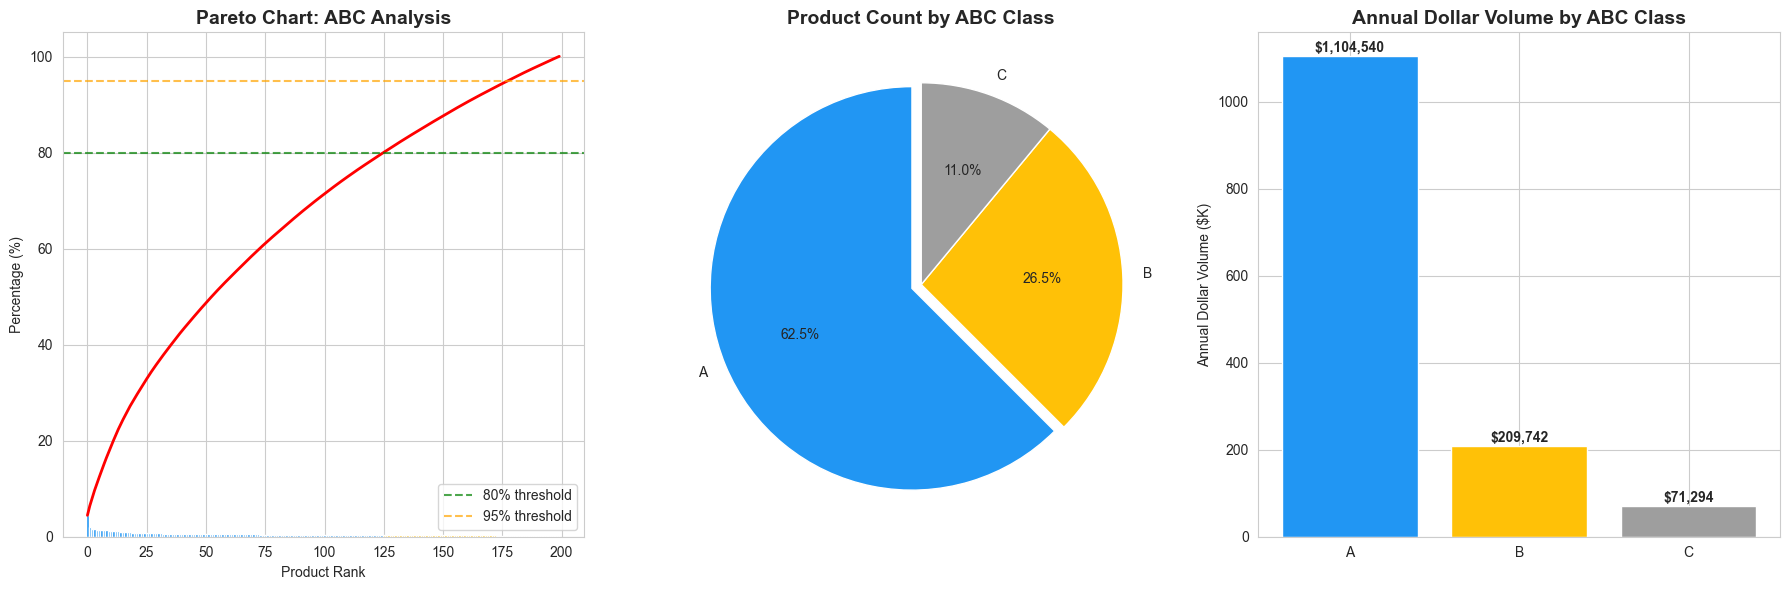

✅ Pareto chart saved to images/abc_analysis.png


In [4]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Pareto Chart
ax = axes[0]
colors = ['#2196F3' if c == 'A' else '#FFC107' if c == 'B' else '#9E9E9E'
          for c in df['ABC_Class']]
ax.bar(range(len(df)), df['Volume_Pct'], color=colors, width=1.0)
ax.plot(range(len(df)), df['Cumulative_Pct'], 'r-', linewidth=2)
ax.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')
ax.set_title('Pareto Chart: ABC Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Rank')
ax.set_ylabel('Percentage (%)')
ax.legend()

# 2. Category Distribution Pie
ax = axes[1]
class_counts = df['ABC_Class'].value_counts()
colors_pie = ['#2196F3', '#FFC107', '#9E9E9E']
ax.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
       colors=colors_pie, startangle=90, explode=(0.05, 0, 0))
ax.set_title('Product Count by ABC Class', fontsize=14, fontweight='bold')

# 3. Volume by ABC Class
ax = axes[2]
volume_by_class = df.groupby('ABC_Class')['Annual_Volume'].sum()
volume_by_class = volume_by_class.reindex(['A', 'B', 'C'])
ax.bar(volume_by_class.index, volume_by_class.values / 1e3, color=colors_pie)
ax.set_title('Annual Dollar Volume by ABC Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Dollar Volume ($K)')
for i, v in enumerate(volume_by_class.values):
    ax.text(i, v/1e3 + 10, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/abc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Pareto chart saved to images/abc_analysis.png')


## 4. 库存策略建议

根据ABC分类结果，为每类产品制定差异化的库存管理策略。


In [5]:
# Define inventory policies by ABC class
policies = pd.DataFrame({
    'ABC_Class': ['A', 'B', 'C'],
    'Review_Frequency': ['Weekly', 'Bi-weekly', 'Monthly'],
    'Service_Level': ['99%', '95%', '90%'],
    'Safety_Stock_Days': [3, 7, 14],
    'Stock_Count_Frequency': ['Cycle count weekly', 'Cycle count monthly', 'Annual physical count'],
    'Recommended_System': ['Continuous review (Q-system)', 'Periodic review (P-system)', 'Two-bin system']
})

display(policies.style.set_caption('Inventory Policies by ABC Classification'))

# Products in each class
print('\n🔹 Class A Products (top 5 by volume):')
class_a = df[df['ABC_Class'] == 'A'].head(5)
for _, row in class_a.iterrows():
    print(f'  • {row["Product_Name"][:50]:50s} | Volume: ${row["Annual_Volume"]:>10,.2f} | Demand: {row["Annual_Demand"]:>4d} units')

print('\n🔹 Class C Products (sample of 5):')
class_c = df[df['ABC_Class'] == 'C'].head(5)
for _, row in class_c.iterrows():
    print(f'  • {row["Product_Name"][:50]:50s} | Volume: ${row["Annual_Volume"]:>10,.2f} | Demand: {row["Annual_Demand"]:>4d} units')


,ABC_Class,Review_Frequency,Service_Level,Safety_Stock_Days,Stock_Count_Frequency,Recommended_System
0,A,Weekly,99%,3,Cycle count weekly,Continuous review (Q-system)
1,B,Bi-weekly,95%,7,Cycle count monthly,Periodic review (P-system)
2,C,Monthly,90%,14,Annual physical count,Two-bin system



🔹 Class A Products (top 5 by volume):
  • Canon imageCLASS 2200 Advanced Copier              | Volume: $ 61,599.82 | Demand:   20 units
  • Fellowes PB500 Electric Punch Plastic Comb Binding | Volume: $ 27,453.38 | Demand:   31 units
  • Cisco TelePresence System EX90 Videoconferencing U | Volume: $ 22,638.48 | Demand:    6 units
  • HON 5400 Series Task Chairs for Big and Tall       | Volume: $ 21,870.58 | Demand:   39 units
  • GBC DocuBind TL300 Electric Binding System         | Volume: $ 19,823.48 | Demand:   37 units

🔹 Class C Products (sample of 5):
  • O'Sullivan Living Dimensions 5-Shelf Bookcases     | Volume: $  3,420.77 | Demand:   21 units
  • Geemarc AmpliPOWER60                               | Volume: $  3,415.04 | Demand:   46 units
  • Hewlett-Packard Desktjet 6988DT Refurbished Printe | Volume: $  3,404.50 | Demand:    5 units
  • Bush Advantage Collection Round Conference Table   | Volume: $  3,401.60 | Demand:   19 units
  • Fellowes Stor/Drawer Steel Plus Storage 

## 5. 关键发现

1. **集中度分析：** 少数A类产品占据了绝大部分库存价值，需优先投入管理资源
2. **成本差异：** A类产品平均单价远高于C类，单位库存持有成本更高
3. **管理建议：** A类采用连续盘点策略，C类可采用简化的双箱系统以降低管理成本
